Dataset Shape: (200, 8)
   applicant_income  coapplicant_income  loan_amount  loan_term  credit_score  \
0             35795               23078       123847        300           309   
1             20860               35153       132750        360           541   
2             96820               11111       260706        360           550   
3             74886               37504        78251        300           304   
4             26265                1802       153481        240           418   

   employment_years  existing_loans  Loan_Approval  
0                 4               0              0  
1                 5               3              0  
2                 3               0              0  
3                18               0              1  
4                19               3              0  

--- Performance ---
Accuracy: 0.5666666666666667
Precision: 0.5789473684210527
Recall: 0.6875
F1 Score: 0.6285714285714286
Confusion Matrix:
 [[12 16]
 [10 22]]


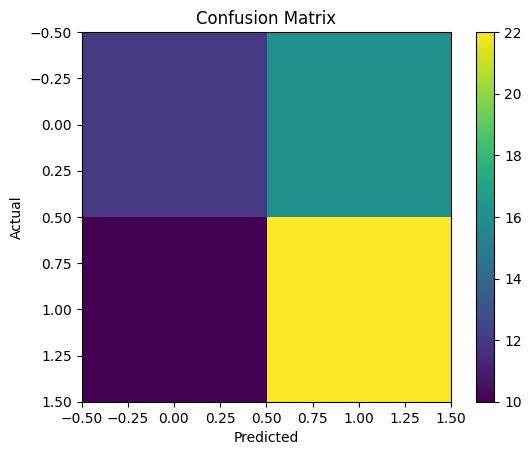


--- New Prediction ---
Prediction (0=Reject, 1=Approve): 0


In [1]:
# ============================
# IMPORT LIBRARIES
# ============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ============================
# (i) READ DATASET
# ============================
df = pd.read_csv("loan_approval_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ============================
# (ii) SEPARATE FEATURES & TARGET
# ============================
X = df.drop("Loan_Approval", axis=1)
y = df["Loan_Approval"]

# ============================
# (iii) TRAIN-TEST SPLIT (70:30)
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ============================
# (iv) TRAIN DECISION TREE
# ============================
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

# ============================
# (v) PREDICT TEST DATA
# ============================
y_pred = model.predict(X_test)

# ============================
# (vi) EVALUATION
# ============================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Performance ---")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

# ============================
# CONFUSION MATRIX PLOT
# ============================
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()
plt.show()

# ============================
# (vii) PREDICT NEW DATA
# ============================
print("\n--- New Prediction ---")

new_data = [[50000, 20000, 150000, 360, 700, 5, 1]]

prediction = model.predict(new_data)

print("Prediction (0=Reject, 1=Approve):", prediction[0])